# 01 — Muons, and what happens when they hit rock

*Weeks 1–2*

Two facts do all the work in muography.

**Fact one.** Cosmic rays hitting the top of the atmosphere produce muons, and
about 10,000 of them pass through every square metre of the ground every
minute. They are free, they are everywhere, and nobody has to pay for the beam.

**Fact two.** A muon loses energy slowly as it ploughs through matter — roughly
2 MeV for every gram per square centimetre it crosses. So a muon with enough
energy gets through a mountain, and one without enough energy stops inside it.

Put the two together and you have an X-ray machine the size of the sky.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../code'))
import numpy as np
import matplotlib.pyplot as plt
import muography as mg
print('ready')

ready


## The spectrum

`mg.gaisser_flux(E, theta)` gives the flux of muons at energy `E` arriving at
zenith angle `theta` (in radians; 0 means straight overhead).

Run this, then look at it properly. Which direction has more high-energy muons
— overhead, or near the horizon? Why might that be?

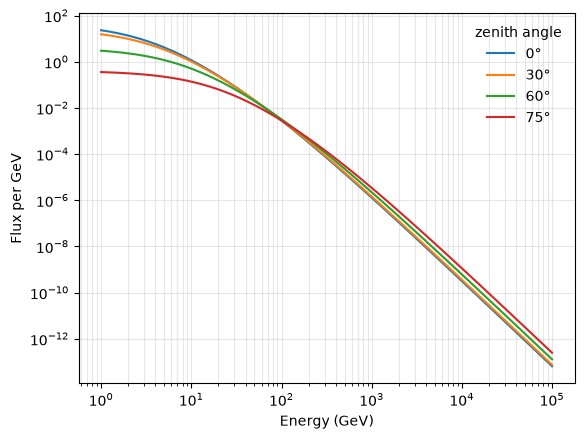

In [4]:
E = np.logspace(0, 5, 300)
for deg in [0, 30, 60, 75]:
    plt.loglog(E, mg.gaisser_flux(E, np.radians(deg)), label=f'{deg}\u00b0')
plt.xlabel('Energy (GeV)'); plt.ylabel('Flux per GeV')
plt.legend(title='zenith angle', frameon=False); plt.grid(alpha=0.3, which='both')
plt.savefig('../figures/01_spectrum_angles.png', dpi=300, bbox_inches='tight')
plt.show()

# Which direction has more high-energy muons?
The larger zenith angles have relatively more high-energy muons compared to low-energy muons. In other words, the spectrum is “harder” at large zenith angles.

# Why?
Muons produced at large zenith angles travel through more atmosphere before reaching sea level. Low-energy muons are more likely to decay or interact before reaching the ground. High-energy muons survive because of time dilation (their lifetime is extended) and because their interaction probability is lower. So the surviving spectrum at large zenith angles is enriched in high-energy muons.

## How many muons in total?

The spectrum tells you how many muons there are *at* each energy. Usually you
want how many there are *above* some energy — because that is what survives a
given thickness of rock. `mg.integrated_flux` does that sum for you.

**Check yourself:** the flux above 1 GeV, straight overhead, should come out
around 60 muons per square metre per second per steradian. This is a number
worth remembering; it is the one every muon physicist quotes from memory.

In [5]:
for E_min in [1, 10, 100, 1000]:
    print(f'above {E_min:5d} GeV : {float(mg.integrated_flux(E_min, 0.0)):10.4f}  m^-2 s^-1 sr^-1')

above     1 GeV :    60.1410  m^-2 s^-1 sr^-1
above    10 GeV :     8.5083  m^-2 s^-1 sr^-1
above   100 GeV :     0.1326  m^-2 s^-1 sr^-1
above  1000 GeV :     0.0005  m^-2 s^-1 sr^-1


 Because the muon spectrum falls as roughly E^-2.7, raising the minimum energy threshold by a factor of 10 cuts the surviving muon rate by a factor of hundreds or more, so only the rare high-energy tail can penetrate thick rock.

## Opacity — the only measure of thickness that matters

A muon does not care whether it crosses 1 metre of lead or 10 metres of water.
It cares about the total mass in its way. So we measure thickness in **opacity**:

$$\text{opacity} = \text{density} \times \text{path length}$$

measured in grams per square centimetre. One metre of limestone
(2.5 g/cm³) is 250 g/cm².

### YOUR TURN

Using `mg.opacity_from_thickness` and `mg.minimum_energy`, make a plot of the
minimum energy a muon needs against the thickness of limestone it must cross,
from 1 m to 400 m.

**Check yourself:** 100 m of limestone should require somewhere near 50 GeV.

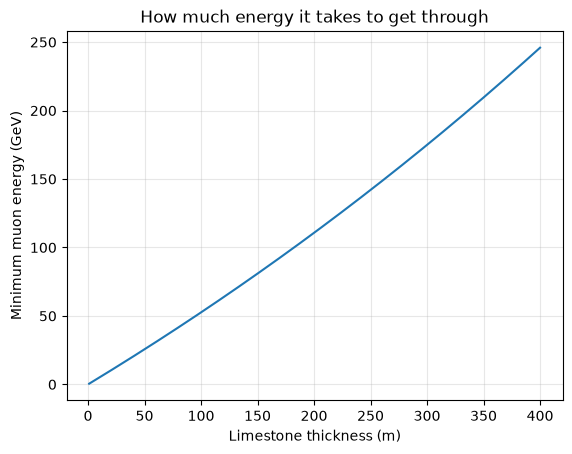

In [6]:
# YOUR TURN
thickness_m = np.linspace(1, 400, 200)
opacity = mg.opacity_from_thickness(thickness_m, density=mg.RHO_LIMESTONE)
E_min = mg.minimum_energy(opacity)

plt.plot(thickness_m, E_min)
plt.xlabel('Limestone thickness (m)')
plt.ylabel('Minimum muon energy (GeV)')
plt.title('How much energy it takes to get through')
plt.grid(alpha=0.3)
plt.savefig('../figures/03_min_energy.png', dpi=300, bbox_inches='tight')
plt.show()

## Putting it together: what survives?

Now the important one. `mg.transmitted_flux(opacity, theta)` chains the two
steps together: it works out the energy needed, then counts how many muons in
the sky have at least that much.

### YOUR TURN

Plot the surviving flux against limestone thickness from 1 m to 400 m. Use a
**logarithmic** y-axis (`plt.semilogy`).

Then answer, in a markdown cell below your plot:

1. Roughly how much does the flux drop between 50 m and 200 m of rock?
2. A detector of area 0.25 m² looks at a patch of sky 2° × 2° wide
   (that is 0.0012 steradian). Under 100 m of limestone, how many muons does it
   collect in one day? *(flux × area × solid angle × 86400 s)*
3. Does that number surprise you? Is it bigger or smaller than you expected?

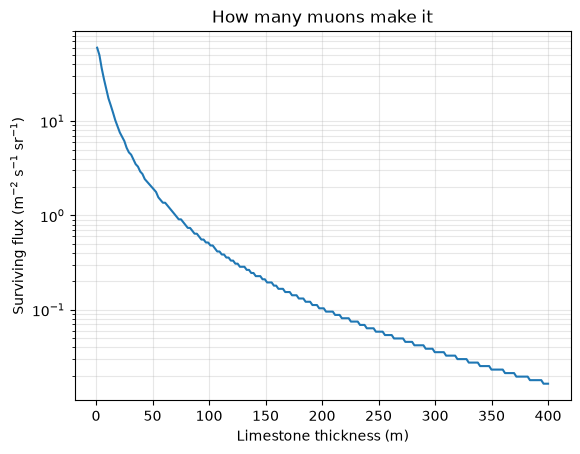

In [7]:
# YOUR TURN
flux = mg.transmitted_flux(opacity, theta=0.0)
plt.semilogy(thickness_m, flux)
plt.xlabel('Limestone thickness (m)')
plt.ylabel('Surviving flux (m$^{-2}$ s$^{-1}$ sr$^{-1}$)')
plt.title('How many muons make it')
plt.grid(alpha=0.3, which='both')
plt.savefig('../figures/04_surviving_flux.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
f50 = float(mg.transmitted_flux(mg.opacity_from_thickness(50), 0.0))
f200 = float(mg.transmitted_flux(mg.opacity_from_thickness(200), 0.0))
print(f50, f200, f50/f200)

1.7423562950488714 0.08937665663921529 19.494534261694316


In [9]:
opacity_100m = mg.opacity_from_thickness(100)
f100 = float(mg.transmitted_flux(opacity_100m, 0.0))
pixel_sr = np.deg2rad(2.0)**2
area = 0.25
T = 86400
N = f100 * area * pixel_sr * T
print(N)

11.49900877254351


I expected the surviving flux through 100 m of limestone to be much larger. Getting only about 10 muons per day in a 0.25 m² patch of sky means that a single day of data is dominated by Poisson noise. This is why the project needs multi-day or multi-week exposures to see a 10 m radius chamber at 5σ.

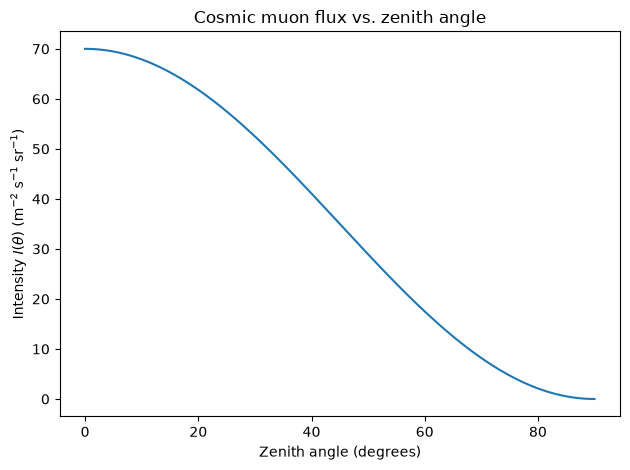

In [10]:
theta = np.linspace(0, np.pi/2, 200)
I_v = 70.0
I = I_v * np.cos(theta)**2
plt.plot(np.degrees(theta), I)
plt.xlabel("Zenith angle (degrees)")
plt.ylabel(r"Intensity $I(\theta)$ (m$^{-2}$ s$^{-1}$ sr$^{-1}$)")
plt.title("Cosmic muon flux vs. zenith angle")
plt.tight_layout()
plt.savefig('../figures/02_flux_vs_angle.png', dpi=300, bbox_inches='tight')
plt.show()

### Where this is going

Question 2 is the seed of the entire project. If a detector collects only a
handful of muons per day, then any conclusion you draw from one day of data is
going to be dominated by luck. Making that statement precise — and turning it
into a number of days — is what notebooks 04 and 05 are about.